# Cell 1: Install Required Packages

In [ ]:
%pip install \
    requests \
    pandas \
    numpy \
    jsonlines \
    sentence-transformers \
    chromadb \
    tqdm \
    matplotlib \
    pydantic \
    transformers \
    seaborn


Note: you may need to restart the kernel to use updated packages.


# Cell 2: Import Libraries

In [ ]:
# Standard Library
import os
import json
import re
import textwrap
import requests
import time
import hashlib
import sys
import logging
from time import perf_counter
from datetime import datetime, timedelta
from pathlib import Path
from typing import Optional, List

# Third-Party Libraries
# Data Handling & Analysis
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Validation & Parsing
from pydantic import BaseModel, ValidationError, field_validator

# Machine Learning & AI
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
from transformers import AutoTokenizer, AutoModelForCausalLM

# Progress Tracking
from tqdm import tqdm

# Other Utilities
import warnings

# Initialisation & Configuration
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)

c:\Users\ossam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Cell 3: Set Up Ollama Configuration and Generation Function

In [ ]:
# Base Ollama configuration
OLLAMA_HOST = "http://localhost:11434"
OLLAMA_MODEL = "mistral"  # Change accordingly [mistral:latest, qwen2.5:7b-instruct, deepseek-llm:7b, llama3:latest, zephyr:latest]
MAX_TOKENS = 1024
def generate(prompt: str, model: str = OLLAMA_MODEL, max_tokens: int = MAX_TOKENS) -> str:
    """
    Query a locally running Ollama LLM for completion.
    Returns the model's output as plain text.
    """
    url = f"{OLLAMA_HOST}/api/generate"
    headers = {"Content-Type": "application/json"}
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.1,
            "num_predict": max_tokens
        }
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()
        return data.get("response", "").strip()

    except requests.exceptions.RequestException as e:
        print("Ollama request failed:", e)
        return ""

print(generate('Return {"ok": true} as valid JSON.'))


Here is the JSON representation of your request:

```json
{
  "ok": true
}
```


# Cell 4: Safe LLM Generation with Retry Logic

In [ ]:
def safe_generate(prompt: str, max_retries: int = 3, delay: float = 1.5) -> str:
    """
    Sends a prompt to the local Ollama LLM with retry logic and basic fallback.
    """
    for attempt in range(max_retries):
        try:
            response = generate(prompt)
            if response:
                return response.strip()  # Return if successful
        except Exception as e:
            print(f"[Attempt {attempt+1}] LLM generation failed: {e}")
        time.sleep(delay)  # Wait before retrying
    raise RuntimeError("LLM generation failed after multiple attempts.")


In [ ]:
# IN_PATH  = Path(r"C:\Users\ossam\OneDrive\Documents\Master's Disseratation 2025\Datasets\appointments_data.json")
# OUT_PATH = Path("appointments_data.normalised.json")

# DT_FORMATS = ("%Y-%m-%d %H:%M:%S", "%Y/%m/%d %H:%M:%S")

# def parse_dt(s: str):
#     if not isinstance(s, str): return None
#     for fmt in DT_FORMATS:
#         try:
#             return datetime.strptime(s, fmt)
#         except ValueError:
#             continue
#     return None

# def fmt_dt(dt: datetime) -> str:
#     return dt.strftime("%Y-%m-%d %H:%M:%S")

# def normalise_appointment_times(rec: dict) -> dict:
#     start = rec.get("startDateTime")
#     end   = rec.get("endDateTime")
#     dur   = rec.get("duration")

#     try:
#         dur = int(dur) if dur is not None and str(dur).strip() != "" else None
#     except Exception:
#         dur = None

#     dt_start = parse_dt(start)
#     dt_end   = parse_dt(end) if end is not None else None

#     if dt_start and dur and dur > 0:
#         if (dt_end is None) or (dt_end == dt_start):
#             computed_end = dt_start + timedelta(minutes=dur)
#             rec["endDateTime"] = fmt_dt(computed_end)

#     return rec

# def run():
#     data = json.loads(Path(IN_PATH).read_text(encoding="utf-8"))
#     results = data.get("results") or data
#     if isinstance(results, list):
#         for i, r in enumerate(results):
#             results[i] = normalise_appointment_times(r)
#     else:
#         data = normalise_appointment_times(data)

#     Path(OUT_PATH).write_text(json.dumps(data, indent=2), encoding="utf-8")
#     print(f"Normalised appointments written → {OUT_PATH}")

# run()


Only needs to be run once, then comment it out, this function normalises the temporal fields. It calculates the correct end time based on the 'Duration'.

# Cell 5: Load Raw Data and Construct RAG Reference Pack

In [ ]:
# Define paths to local input JSON files
PATH_APPTS_RAW = r"C:\Users\ossam\OneDrive\Documents\Master's Disseratation 2025\Datasets\appointments_data.normalised.json"
PATH_PRACTITIONERS_RAW = r"C:\Users\ossam\OneDrive\Documents\Master's Disseratation 2025\Datasets\client_data 1.json"
PATH_PRACTITIONERS_XFORM = r"C:\Users\ossam\OneDrive\Documents\Master's Disseratation 2025\Datasets\transformed_output 1.json"

def _safe_load(path):
    """Safely load a JSON file from disk."""
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# Load raw and transformed datasets
pract_raw = _safe_load(PATH_PRACTITIONERS_RAW)
pract_xf  = _safe_load(PATH_PRACTITIONERS_XFORM)
appts_raw = _safe_load(PATH_APPTS_RAW)

# Schema definitions for grounding the transformation task
SCHEMA_PRACT = textwrap.dedent("""
Schema: practitioner (users table)
Required: id:int (keep), first_name:str (forename), last_name:str (surname), practice_id:int (defaultLocationId)
Optional: title:enum{Mr,Mrs,Miss,Ms,Mx,Sir,Dr,Lady,Lord,Master,Prof,Other} (trim '.'),
email, gender, type, status:int, online:bool, employment_status, service_type_id:int,
commission_flat_rate:int, commission_percent:int, time_slot:int, location_ids:[int],
default_location_id:int, location_name, address_line_1, address_line_2, town_city, state_county,
postcode_zipcode, country, phone_number, mobile, online_guid, skills:[str]
Rules: keep numeric IDs unchanged; title trim '.'; invalid title → null; phone → digits only (length < 10 → null);
postcode alphanumeric (spaces allowed) else null; omit null or empty fields.
""").strip()

SCHEMA_APPT = textwrap.dedent("""
Schema: appointment (appointments table)
Allowed keys only: id, location_id, patient_id, practitioner_id, status, start_time, end_time, title, description
Mapping: start_time ← startDateTime, end_time ← endDateTime, patient_id ← customerId,
practitioner_id ← practitionerId, location_id ← locationId
Status map: 1 draft, 2 completed, 3 Arrived, 4 Did Not Arrive
Title: trim '.'; invalid → null; return a single valid JSON object; omit null or empty.
""").strip()

# Rule snippets to inject into prompts
TITLE_RULES  = "Valid titles: Mr,Mrs,Miss,Ms,Mx,Sir,Dr,Lady,Lord,Master,Prof,Other. Remove trailing '.' before validation."
STATUS_RULES = "Status mapping: 1→draft, 2→completed, 3→Arrived, 4→Did Not Arrive."

# Construct practitioner example pairs using raw and transformed records
prac_examples = []
for i in range(min(2, len(pract_raw.get('results', [])), len(pract_xf))):
    before = pract_raw['results'][i]
    after  = pract_xf[i]
    prac_examples.append({
        "id": f"ex:practitioner:{i+1}",
        "type": "example",
        "schema": "practitioner",
        "text": f"BEFORE:\n{json.dumps(before, indent=2)}\n\nAFTER:\n{json.dumps(after, indent=2)}"
    })

# Construct appointment examples using field mapping and status rules
appt_examples = []
_status_map = {1: "draft", 2: "completed", 3: "Arrived", 4: "Did Not Arrive"}

for i in range(min(2, len(appts_raw.get('results', [])))):
    before = appts_raw['results'][i]
    after = {
        "id": before.get("id"),
        "location_id": before.get("locationId"),
        "patient_id": before.get("customerId"),
        "practitioner_id": before.get("practitionerId"),
        "status": _status_map.get(before.get("status", 1), "draft"),
        "start_time": before.get("startDateTime"),
        "end_time": before.get("endDateTime"),
        "title": (before.get("title") or "").rstrip(".") if before.get("title") else None,
        "description": before.get("description") or before.get("comment") or None
    }
    appt_examples.append({
        "id": f"ex:appointment:{i+1}",
        "type": "example",
        "schema": "appointment",
        "text": f"BEFORE:\n{json.dumps(before, indent=2)}\n\nAFTER:\n{json.dumps(after, indent=2)}"
    })

# Final reference pack for RAG (schemas, rules, and examples)
REFERENCE_PACK = [
    {"id": "schema:practitioner", "type": "schema", "schema": "practitioner", "text": SCHEMA_PRACT},
    {"id": "schema:appointment",  "type": "schema", "schema": "appointment",  "text": SCHEMA_APPT},
    {"id": "rules:title",         "type": "rule",   "schema": "both",         "text": TITLE_RULES},
    {"id": "rules:status",        "type": "rule",   "schema": "appointment",  "text": STATUS_RULES},
    *prac_examples,
    *appt_examples
]

print("Reference docs:", len(REFERENCE_PACK), [doc["id"] for doc in REFERENCE_PACK])


Reference docs: 8 ['schema:practitioner', 'schema:appointment', 'rules:title', 'rules:status', 'ex:practitioner:1', 'ex:practitioner:2', 'ex:appointment:1', 'ex:appointment:2']


Loads practitioner and appointment datasets from local Windows paths. Constructs schema descriptions, rule references, and structured before–after examples used as RAG grounding data. Final output is a REFERENCE_PACK list containing all schema, rule, and example entries.

# Cell 6: Load and Inspect Original Appointment Records

In [ ]:
# Load the original appointments file
with open(PATH_APPTS_RAW, 'r', encoding='utf-8') as f:
    original_data = json.load(f)

# Extract the list of appointment records
original_appointments = original_data.get("results", [])

# Print the number of records
print("Original appointment entries:", len(original_appointments))

Original appointment entries: 2500


Loads the original appointments dataset from disk, extracts the list of records under the "results" key, and prints the total count. This confirms the number of entries before transformation.

# Cell 7: Initialise and Seed ChromaDB Vector Store

In [ ]:
# Create and seed a ChromaDB vector store using sentence-transformer embeddings

# Load embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Initialise ChromaDB in-memory (no persistent storage)
client = chromadb.Client(Settings(is_persistent=False))

# Create a collection for storing reference documents
col = client.create_collection("rag-osteopathy1")

def _emb(texts):
    """
    Embed a list of text strings using the sentence-transformers model.
    Embeddings are L2-normalised.
    """
    return embedder.encode(texts, normalize_embeddings=True).tolist()

def add_docs(docs):
    """
    Add documents to the vector store with IDs, text, metadata, and precomputed embeddings.
    """
    col.add(
        ids=[d["id"] for d in docs],
        documents=[d["text"] for d in docs],
        metadatas=[{"type": d["type"], "schema": d["schema"]} for d in docs],
        embeddings=_emb([d["text"] for d in docs])
    )

def where_meta(*, schema: str | None = None, doc_type: str | None = None):
    """
    Construct a ChromaDB filter.
    If both schema and type are provided, use an AND clause.
    """
    clauses = []
    if doc_type:
        clauses.append({"type": doc_type})
    if schema:
        clauses.append({"schema": schema})
    if not clauses:
        return None
    if len(clauses) == 1:
        return clauses[0]
    return {"$and": clauses}

def topk(query: str, k: int = 4, where: dict | None = None):
    """
    Retrieve the top-k documents most similar to the query.
    Optional filtering can be applied using `where`.
    """
    res = col.query(
        query_embeddings=_emb([query]),
        n_results=k,
        where=where
    )
    return [
        {"id": res["ids"][0][i], "text": res["documents"][0][i], "meta": res["metadatas"][0][i]}
        for i in range(len(res["ids"][0]))
    ]

# Add your schema, rule, and example documents to the collection
add_docs(REFERENCE_PACK)

print("Chroma seeded. Document count:", col.count())


2025-09-18 13:19:43,730 - INFO - Use pytorch device_name: cpu
2025-09-18 13:19:43,731 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2025-09-18 13:19:45,526 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]

Chroma seeded. Document count: 8


Initialises an in-memory ChromaDB vector store using sentence-transformer embeddings (all-MiniLM-L6-v2). Embeds and indexes all documents from the REFERENCE_PACK (schemas, rules, examples), and provides helper functions for embedding, filtering, and top-k retrieval with optional metadata filtering.

# Cell 8: Prompt Construction and JSON Extraction Utilities

In [ ]:
BASE_SYSTEM = (
    "You are a careful data transformer.\n"
    "- Output strictly valid JSON only, using double quotes.\n"
    "- Do not include explanations, markdown, or code fences.\n"
)

def join_chunks(chunks, max_chars=2800):
    """
    Join a list of text chunks into a single string, truncated to a character limit.
    """
    out, total_len = [], 0
    for t in chunks:
        t = (t or "").strip()
        if not t:
            continue
        if total_len + len(t) > max_chars:
            break
        out.append(t)
        total_len += len(t)
    return "\n\n---\n\n".join(out)

def _truncate_record(rec: dict, max_chars: int = 3000) -> str:
    """
    Truncate a JSON record if it exceeds the character limit.
    """
    txt = json.dumps(rec, ensure_ascii=False)
    return txt if len(txt) <= max_chars else txt[:max_chars] + "...(truncated)"

def prompt_practitioner(record: dict):
    """
    Build a structured prompt for transforming a practitioner record.
    """
    q = json.dumps(record, ensure_ascii=False)[:1500]

    schemas = [d["text"] for d in topk(q, k=2, where=where_meta(schema="practitioner", doc_type="schema"))]
    rules   = [d["text"] for d in topk("practitioner title phone postcode rules", k=2, where=where_meta(doc_type="rule"))]
    exs     = [d["text"] for d in topk(q, k=3, where=where_meta(schema="practitioner", doc_type="example"))]

    allowed = (
        "Allowed keys only: id, first_name, last_name, practice_id, title, email, gender, type, status, online, "
        "employment_status, service_type_id, commission_flat_rate, commission_percent, time_slot, location_ids, "
        "default_location_id, location_name, address_line_1, address_line_2, town_city, state_county, "
        "postcode_zipcode, country, phone_number, mobile, online_guid, skills."
    )

    return f"""{BASE_SYSTEM}
# Schema
{join_chunks(schemas)}

# Rules
{join_chunks(rules)}

# Examples
{join_chunks(exs)}

{allowed}
Remove all newline characters (\\n) or line breaks from string fields like address_line_1, address_line_2, and description. Replace them with a single space.

Return a single JSON object with only non-null fields.

Input:
{_truncate_record(record)}
"""

def prompt_appointment(record: dict):
    """
    Build a structured prompt for transforming an appointment record.
    """
    q = json.dumps(record, ensure_ascii=False)[:1500]

    schemas = [d["text"] for d in topk(q, k=2, where=where_meta(schema="appointment", doc_type="schema"))]
    rules   = [d["text"] for d in topk("appointment status mapping", k=1, where=where_meta(schema="appointment", doc_type="rule"))]
    exs     = [d["text"] for d in topk(q, k=3, where=where_meta(schema="appointment", doc_type="example"))]

    allowed = (
        "Only include keys: id, location_id, patient_id, practitioner_id, status, start_time, end_time, title, description."
    )

    return f"""{BASE_SYSTEM}
# Schema
{join_chunks(schemas)}

# Rules
{join_chunks(rules)}

# Examples
{join_chunks(exs)}

{allowed}
Remove all newline characters (\\n) or line breaks from string fields like address_line_1, address_line_2, and description. Replace them with a single space.

Return a single JSON object with only non-null fields.

Input:
{_truncate_record(record)}
"""

def extract_json(text: str) -> dict:
    """
    Parse a string into a JSON object, with light patching for minor formatting issues.
    """
    if not isinstance(text, str):
        raise ValueError("LLM output is not a string")
    s = text.strip()

    obj_match = re.search(r"\{[\s\S]*\}$", s)
    if obj_match:
        block = obj_match.group(0)
    else:
        arr_match = re.search(r"\[[\s\S]*\]$", s)
        block = arr_match.group(0) if arr_match else s

    def _parse(b):
        data = json.loads(b)
        if isinstance(data, list):
            data = data[0] if data else {}
        if not isinstance(data, dict):
            raise ValueError("Top-level JSON is not an object")
        return data

    try:
        return _parse(block)
    except Exception:
        patched = block.replace("'", '"')
        patched = re.sub(r",\s*([}\]])", r"\1", patched)
        return _parse(patched)


Retrieval-Augmented Generation (RAG) is explicitly and deliberately injected into the LLM prompt construction process. The program isn't relying on some abstract intergration. This cell constructs context-aware prompts for the LLM by dynamically retrieving relevant schema definitions, transformation rules, and example transformations from ChromaDB. It uses these to guide the LLM in converting raw records into structured, schema-compliant JSON.

# Cell 9: Define Pydantic Validation Models for Structured Output

In [ ]:
# Define a schema-compliant practitioner record with strict validation rules
class PractitionerRecord(BaseModel):
    id: int
    first_name: Optional[str] = None
    last_name: Optional[str] = None
    practice_id: Optional[int] = None
    title: Optional[str] = None
    email: Optional[str] = None
    gender: Optional[str] = None
    type: Optional[str] = None
    status: Optional[int] = None
    online: Optional[bool] = None
    employment_status: Optional[str] = None
    service_type_id: Optional[int] = None
    commission_flat_rate: Optional[int] = None
    commission_percent: Optional[int] = None
    time_slot: Optional[int] = None
    location_ids: Optional[List[int]] = None
    default_location_id: Optional[int] = None
    location_name: Optional[str] = None
    address_line_1: Optional[str] = None
    address_line_2: Optional[str] = None
    town_city: Optional[str] = None
    state_county: Optional[str] = None
    postcode_zipcode: Optional[str] = None
    country: Optional[str] = None
    phone_number: Optional[str] = None
    mobile: Optional[str] = None
    online_guid: Optional[str] = None
    skills: Optional[List[str]] = []

    # Validator: Strip trailing full stops and allow only known titles
    @field_validator('title')
    def validate_title(cls, v: Optional[str]) -> Optional[str]:
        if not v:
            return None
        valid_titles = ['Mr', 'Mrs', 'Miss', 'Ms', 'Mx', 'Sir', 'Dr', 'Lady',
                        'Lord', 'Master', 'Prof', 'Other']
        clean_title = v.rstrip('.')
        if clean_title not in valid_titles:
            return None
        return clean_title

    # Validator: Accept emails with '@' only; discard invalid formats
    @field_validator('email')
    def validate_email(cls, v: Optional[str]) -> Optional[str]:
        if v and '@' not in v:
            return None
        return v

    # Validator: Keep only numeric digits; discard short numbers
    @field_validator('phone_number', 'mobile')
    def validate_phone(cls, v: Optional[str]) -> Optional[str]:
        if v:
            clean = ''.join(filter(str.isdigit, v))
            if len(clean) < 10:
                return None
            return clean
        return None

    # Validator: Drop non-string or empty skill entries
    @field_validator('skills')
    def validate_skills(cls, v: Optional[List[str]]) -> Optional[List[str]]:
        if v:
            clean_skills = [s for s in v if isinstance(s, str) and s.strip()]
            return clean_skills or None
        return None

    # Validator: Accept only alphanumeric postcodes (spaces allowed)
    @field_validator('postcode_zipcode')
    def validate_postcode(cls, v: Optional[str]) -> Optional[str]:
        if v and not v.replace(' ', '').isalnum():
            return None
        return v

    # Validator: Remove newline characters and other noise from free text fields
    @field_validator(
        'address_line_1', 'address_line_2',
        'town_city', 'state_county',
        'country', 'location_name', 'online_guid',
        mode='before'
    )
    def clean_text_nlp_noise(cls, v):
        if v and isinstance(v, str):
            return re.sub(r"[\n\r\t]+", " ", v).strip()
        return v


class AppointmentRecord(BaseModel):
    id: int
    location_id: Optional[int] = None
    patient_id: Optional[int] = None
    practitioner_id: Optional[int] = None
    status: Optional[str] = None
    start_time: Optional[str] = None
    end_time: Optional[str] = None
    title: Optional[str] = None
    description: Optional[str] = None

    @field_validator("title")
    def validate_title(cls, v: Optional[str]) -> Optional[str]:
        if not v:
            return None
        valid_titles = ["Mr", "Mrs", "Miss", "Ms", "Mx", "Sir", "Dr",
                        "Lady", "Lord", "Master", "Prof", "Other"]
        clean_title = v.rstrip(".")
        if clean_title not in valid_titles:
            return None
        return clean_title

    @field_validator("start_time", "end_time", mode="before")
    def validate_time_format(cls, v: Optional[str]) -> Optional[str]:
        if v:
            try:
                datetime.fromisoformat(v)
            except ValueError:
                try:
                    datetime.strptime(v, "%Y-%m-%d %H:%M:%S")
                except ValueError:
                    raise ValueError(f"Invalid datetime format: {v}")
        return v

    @field_validator("description", mode="before")
    def clean_description(cls, v):
        if v and isinstance(v, str):
            return re.sub(r"[\n\r\t]+", " ", v).strip()
        return v



# Define field-level whitelist sets for both schemas
ALLOWED_PRACT_KEYS = set(PractitionerRecord.model_fields.keys())
ALLOWED_APPT_KEYS = set(AppointmentRecord.model_fields.keys())

# Utility to remove extraneous keys not part of the schema
def keep_only(d: dict, allowed_keys: set) -> dict:
    return {k: v for k, v in d.items() if k in allowed_keys}


This cell defines two strict Pydantic models (PractitionerRecord and AppointmentRecord) to enforce schema compliance and clean LLM outputs. These models validate field types, apply domain-specific rules (e.g. title normalisation, date format, postcode structure), and serve as the final gatekeeper for JSON validity before archiving or downstream use.

# Cell 10: Transform Records via LLM with Fallback on Failure

In [ ]:
def transform_practitioner(record: dict) -> dict:
    """
    Attempts to transform a practitioner record using the LLM.
    Falls back to rules-based logic on failure.
    """
    prompt = prompt_practitioner(record)
    output = safe_generate(prompt)

    try:
        parsed = extract_json(output)
        filtered = keep_only(parsed, ALLOWED_PRACT_KEYS)
        validated = PractitionerRecord(**filtered).model_dump(exclude_none=True)
        return validated
    except Exception as e:
        print("[Fallback] LLM failed for practitioner:", e)
        return fallback_practitioner(record)


def transform_appointment(record: dict) -> dict:
    """
    Attempts to transform an appointment record using the LLM.
    Falls back to rules-based logic on failure.
    """
    prompt = prompt_appointment(record)
    output = safe_generate(prompt)

    try:
        parsed = extract_json(output)
        filtered = keep_only(parsed, ALLOWED_APPT_KEYS)
        validated = AppointmentRecord(**filtered).model_dump(exclude_none=True)
        return validated
    except Exception as e:
        print("[Fallback] LLM failed for appointment:", e)
        return fallback_appointment(record)


Executes the transformation pipeline for each record type:

 - Builds a prompt using the appropriate prompt constructor.

 - Sends it to the LLM with retries (safe_generate).

 - Parses, filters, and validates the output via Pydantic.

 - If any part fails (invalid JSON, schema errors), falls back to rule-based transformation (fallback_practitioner / fallback_appointment).

# Cell 11: Define Rule-Based Fallback Logic for Record Transformation

In [ ]:
def _as_int(x):
    try:
        return int(x) if x is not None and str(x).strip() != "" else None
    except Exception:
        return None

def _digits_only(s):
    return re.sub(r"\D+", "", s) if s else None

def fallback_practitioner(record: dict) -> dict:
    return {
        "id": _as_int(record.get("id") or record.get("userId")),
        "first_name": record.get("forename") or record.get("firstName"),
        "last_name": record.get("surname") or record.get("lastName"),
        "title": (record.get("title") or "").rstrip(".") or None,
        "practice_id": _as_int(record.get("defaultLocationId") or record.get("practiceId")),
        "email": record.get("email"),
        "gender": record.get("gender"),
        "location_name": record.get("locationName"),
        "address_line_1": record.get("addressLine1") or record.get("address_line_1"),
        "postcode_zipcode": record.get("postCode") or record.get("postcode") or record.get("zipcode"),
        "phone_number": _digits_only(record.get("phone") or record.get("phone_number")),
        "mobile": _digits_only(record.get("mobile")),
    }


def fallback_appointment(record: dict) -> dict:
    """
    Minimal fallback transformation for appointment.
    Maps fields directly from known keys.
    """
    status_map = {1: "draft", 2: "completed", 3: "Arrived", 4: "Did Not Arrive"}

    return {
        "id": record.get("id"),
        "location_id": record.get("locationId"),
        "patient_id": record.get("customerId"),
        "practitioner_id": record.get("practitionerId"),
        "status": status_map.get(record.get("status"), "draft"),
        "start_time": record.get("startDateTime"),
        "end_time": record.get("endDateTime"),
        "title": (record.get("title") or "").rstrip(".") if record.get("title") else None,
        "description": record.get("description") or record.get("comment")
    }


Implements deterministic fallback logic when LLM transformation fails.
For each record type:

 - Practitioner: Maps fields directly from known alternative keys, applies light cleaning (e.g. title trimming, digit-only phone numbers).

 - Appointment: Applies field mappings and status translation using a static dictionary.

Also defines two utility functions:

 - _as_int: Safely cast to integer, returning None if invalid.

 - _digits_only: Removes all non-digit characters from phone fields.

# Cell 12: Failure Artifact Logging for Generation and Validation Errors

In [ ]:
FAIL_ROOT = "evaluation_metrics/failures"
os.makedirs(FAIL_ROOT, exist_ok=True)

def _safe_write(path: str, content: str | dict | list):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if isinstance(content, (dict, list)):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(content, f, indent=2, ensure_ascii=False)
    else:
        with open(path, "w", encoding="utf-8") as f:
            f.write(content if isinstance(content, str) else str(content))

def save_failure_artifacts(
    *,
    entity: str,
    record_id: Optional[int | str],
    stage: str,                     # "generation" or "validation"
    error: Exception | str,
    prompt_text: Optional[str] = None,
    raw_output_text: Optional[str] = None,
    retrieved_context: Optional[dict] = None
) -> str:
    """
    Saves prompt, raw LLM output, retrieved context, and error details to disk.
    Returns the artifact directory path.
    """
    rid = record_id if record_id is not None else "unknown"
    ts = datetime.utcnow().strftime("%Y%m%dT%H%M%S")
    artifact_dir = os.path.join(FAIL_ROOT, f"{entity}_{rid}_{stage}_{ts}")

    # Write files
    if prompt_text is not None:
        _safe_write(os.path.join(artifact_dir, "prompt.txt"), prompt_text)

    if raw_output_text is not None:
        # Also keep a short excerpt in case the output is huge
        excerpt = raw_output_text[:1200]
        _safe_write(os.path.join(artifact_dir, "llm_output.txt"), excerpt)

    if retrieved_context is not None:
        _safe_write(os.path.join(artifact_dir, "retrieval.json"), retrieved_context)

    # Error details
    if isinstance(error, Exception):
        err_payload = {
            "type": error.__class__.__name__,
            "str": str(error)
        }
        # Pydantic ValidationError often has .errors()
        try:
            if hasattr(error, "errors"):
                err_payload["details"] = error.errors()
        except Exception:
            pass
    else:
        err_payload = {"type": "StringError", "str": str(error)}

    _safe_write(os.path.join(artifact_dir, "error.json"), err_payload)

    return artifact_dir


Defines structured logging for failed transformations at any stage (generation or validation). When a failure occurs, it saves:

 - The LLM prompt (prompt.txt)

 - The raw LLM output excerpt (llm_output.txt)

 - Any retrieved context used (retrieval.json)

 - Detailed error information (error.json)

Each failure is saved under a timestamped folder in:
evaluation_metrics/failures/<entity>_<record_id>_<stage>_<timestamp>/

# Cell 13: Transformation Logging and Audit Utilities

In [ ]:
import time  # safe if already imported

# For storing performance and audit logs
combined_logs = []

def log_transformation(record_id, method, success, time_taken, stage, error=None,
                       entity=None, model=None, error_type=None, artifact_dir=None,
                       llm_elapsed=None, val_elapsed=None, fb_elapsed=None):
    combined_logs.append({
        "record_id": record_id,
        "method": method,
        "success": success,
        "time": time_taken,
        "stage": stage,
        "error": error,
        "entity": entity,
        "model": model,
        "error_type": error_type,
        "artifact_dir": artifact_dir,
        "llm_elapsed": llm_elapsed,
        "val_elapsed": val_elapsed,
        "fb_elapsed": fb_elapsed
    })


class TransformationAuditor:
    def __init__(self):
        self.results = []

    def record_success(self, entity_type: str, duration: float, used_fallback: bool = False):
        self.results.append({
            "entity": entity_type,
            "success": True,
            "fallback": used_fallback,
            "duration": duration
        })

    def record_failure(self, entity_type: str, duration: float):
        self.results.append({
            "entity": entity_type,
            "success": False,
            "fallback": None,
            "duration": duration
        })

    def summary(self):
        import pandas as pd
        df = pd.DataFrame(self.results)
        if df.empty:
            return "No results."
        return df.groupby(["entity", "success", "fallback"]).size().unstack(fill_value=0)


class PerformanceMonitor:
    """
    Simple utility class to track elapsed time.
    Call .end() before accessing .duration.
    """
    def __init__(self):
        self.start_time = time.time()
        self.duration = None

    def end(self):
        self.duration = time.time() - self.start_time


🔹 log_transformation(...)

Appends per-record metadata to the shared combined_logs list.

Captures model name, success/failure, error type, fallback usage, and time taken.

🔹 TransformationAuditor

Records success/failure and whether fallback was used.

Produces a summary DataFrame for reporting transformation outcomes.

🔹 PerformanceMonitor

Tracks time spent per transformation using start → end logic.

Lightweight, suitable for measuring LLM and fallback latency independently.



Supports accurate per-record tracking of failures, timing, and method.

Enables clean aggregation later by model, entity type, or method.

Keeps the methodology defensible with traceable audit trails.

# Cell 14: Entity Transformation with Reason-Aware Fallback and Failure Logging

In [ ]:
# (Enhanced timings) Accurate stage timings + console logs
def transform_entity(record: dict, entity_type: str, auditor: TransformationAuditor) -> dict | None:
    """
    Main transformation function for practitioner or appointment records.
    Tries LLM-based transformation first; on failure, applies the entity-specific fallback.
    Logs reason, error type, and writes artefacts (prompt/output/retrieval) for inspection.
    Also logs stage-accurate timings (LLM vs validation).
    """

    # Select entity-specific components
    if entity_type == "practitioner":
        prompt_fn = prompt_practitioner
        model_cls = PractitionerRecord
        allowed_keys = ALLOWED_PRACT_KEYS
        fallback_fn = fallback_practitioner
    else:
        prompt_fn = prompt_appointment
        model_cls = AppointmentRecord
        allowed_keys = ALLOWED_APPT_KEYS
        fallback_fn = fallback_appointment

    rec_id = record.get("id")
    perf = PerformanceMonitor()  # keeps total time for our existing combined_logs
    t0 = perf_counter()          # high-res clock for stage timings

    # For artefacts
    retrieved_ctx = None
    try:
        key = f"{entity_type}:{rec_id}"
        if "RETRIEVAL_CONTEXT" in globals():
            retrieved_ctx = RETRIEVAL_CONTEXT.get(key)
    except Exception:
        retrieved_ctx = None

    prompt_text = None
    raw_output_text = None

    try:
        # LLM STAGE
        prompt_text = prompt_fn(record)
        logging.info(f"[{entity_type}] Record {rec_id}: prompt built; sending to {OLLAMA_MODEL}.")

        t_llm_start = perf_counter()
        raw_output_text = safe_generate(prompt_text)
        t_llm_end = perf_counter()
        llm_elapsed = t_llm_end - t_llm_start
        logging.info(f"[{entity_type}] Record {rec_id}: LLM responded ({len(raw_output_text)} chars) in {llm_elapsed:.2f}s.")

        # Parse/filter
        parsed = extract_json(raw_output_text)
        filtered = keep_only(parsed, allowed_keys)

        # VALIDATION STAGE
        t_val_start = perf_counter()
        validated = model_cls(**filtered).model_dump(exclude_none=True)
        t_val_end = perf_counter()
        val_elapsed = t_val_end - t_val_start

        # Success path
        perf.end()  # sets total duration
        total_elapsed = perf.duration if perf.duration is not None else (perf_counter() - t0)

        # Console summary (stage-accurate)
        logging.info(
            f"[{entity_type}] Record {rec_id}: validated via LLM "
            f"(llm={llm_elapsed:.2f}s, validate={val_elapsed:.2f}s, total={total_elapsed:.2f}s)."
        )

        # Persist to combined logs (unchanged API)
        auditor.record_success(entity_type, total_elapsed, used_fallback=False)
        log_transformation(
            record_id=rec_id,
            method="llm",
            success=True,
            time_taken=total_elapsed,
            stage="generation",
            error=None,
            entity=entity_type,
            model=OLLAMA_MODEL,
            error_type=None,
            artifact_dir=None
        )
        return validated

    except ValidationError as val_err:
        # LLM produced JSON but failed schema validation
        perf.end()
        total_elapsed = perf.duration if perf.duration is not None else (perf_counter() - t0)
        logging.error(f"[{entity_type}] Record {rec_id}: validation failed ({val_err.__class__.__name__}); falling back.")

        artifact_dir = save_failure_artifacts(
            entity=entity_type,
            record_id=rec_id,
            stage="validation",
            error=val_err,
            prompt_text=prompt_text,
            raw_output_text=raw_output_text,
            retrieved_context=retrieved_ctx,
        )

        # Fallback attempt
        try:
            t_fb_start = perf_counter()
            candidate = fallback_fn(record)
            filtered = keep_only(candidate, allowed_keys)
            validated = model_cls(**filtered).model_dump(exclude_none=True)
            t_fb_end = perf_counter()
            fb_elapsed = t_fb_end - t_fb_start

            auditor.record_success(entity_type, total_elapsed, used_fallback=True)
            log_transformation(
                record_id=rec_id,
                method="fallback",
                success=True,
                time_taken=total_elapsed,
                stage="validation",
                error=str(val_err),
                entity=entity_type,
                model=OLLAMA_MODEL,
                error_type=val_err.__class__.__name__,
                artifact_dir=artifact_dir
            )
            logging.info(f"[{entity_type}] Record {rec_id}: fallback succeeded in {fb_elapsed:.2f}s (total={total_elapsed:.2f}s).")
            return validated

        except Exception as ve:
            auditor.record_failure(entity_type, total_elapsed)
            log_transformation(
                record_id=rec_id,
                method="fallback",
                success=False,
                time_taken=total_elapsed,
                stage="validation",
                error=str(ve),
                entity=entity_type,
                model=OLLAMA_MODEL,
                error_type=ve.__class__.__name__,
                artifact_dir=artifact_dir
            )
            logging.error(f"[{entity_type}] Record {rec_id}: fallback failed; see artefacts at {artifact_dir}.")
            return None

    except Exception as gen_err:
        # JSON/extraction/LLM response issues
        perf.end()
        total_elapsed = perf.duration if perf.duration is not None else (perf_counter() - t0)
        logging.error(f"[{entity_type}] Record {rec_id}: generation failed ({gen_err.__class__.__name__}); falling back.")

        artifact_dir = save_failure_artifacts(
            entity=entity_type,
            record_id=rec_id,
            stage="generation",
            error=gen_err,
            prompt_text=prompt_text,
            raw_output_text=raw_output_text,
            retrieved_context=retrieved_ctx,
        )

        try:
            t_fb_start = perf_counter()
            candidate = fallback_fn(record)
            filtered = keep_only(candidate, allowed_keys)
            validated = model_cls(**filtered).model_dump(exclude_none=True)
            t_fb_end = perf_counter()
            fb_elapsed = t_fb_end - t_fb_start

            auditor.record_success(entity_type, total_elapsed, used_fallback=True)
            log_transformation(
                record_id=rec_id,
                method="fallback",
                success=True,
                time_taken=total_elapsed,
                stage="generation",
                error=str(gen_err),
                entity=entity_type,
                model=OLLAMA_MODEL,
                error_type=gen_err.__class__.__name__,
                artifact_dir=artifact_dir
            )
            logging.info(f"[{entity_type}] Record {rec_id}: fallback succeeded in {fb_elapsed:.2f}s (total={total_elapsed:.2f}s).")
            return validated

        except Exception as ve:
            auditor.record_failure(entity_type, total_elapsed)
            log_transformation(
                record_id=rec_id,
                method="fallback",
                success=False,
                time_taken=total_elapsed,
                stage="validation",
                error=str(ve),
                entity=entity_type,
                model=OLLAMA_MODEL,
                error_type=ve.__class__.__name__,
                artifact_dir=artifact_dir
            )
            logging.error(f"[{entity_type}] Record {rec_id}: fallback failed; see artefacts at {artifact_dir}.")
            return None


This is the core transformation function that:

Applies LLM-based transformation with structured prompt and context.

Validates the LLM output using schema-specific Pydantic models.

On failure, it:

Distinguishes between generation and validation errors.

Saves relevant artifacts (prompt, output, context, error details).

Falls back to deterministic rule-based logic.

Logs transformation metadata to support later aggregation and visualisation.

This is where everything comes together:

Prompt retrieval (RAG)

Inference (safe_generate)

Validation (Pydantic)

Fallback logic

Performance monitoring

Traceability via logging and saved artifacts

It's your audit-compliant, robust pipeline core, designed for repeatable, comparable, and explainable multi-model runs.

# Cell 15a: (OPTIONAL)

In [ ]:
# # Run transformations and collect results
# auditor = TransformationAuditor()
# results_pract = []
# results_appts = []

# # Process practitioner records
# for rec in tqdm(pract_raw.get("results", []), desc="Transforming practitioners"):
#     output = transform_entity(rec, "practitioner", auditor)
#     if output:
#         results_pract.append(output)

# # Process appointment records
# for rec in tqdm(appts_raw.get("results", []), desc="Transforming appointments"):
#     output = transform_entity(rec, "appointment", auditor)
#     if output:
#         results_appts.append(output)

# # Optional: Save transformed records (you can adjust the paths)
# with open("transformed_practitioners.json", "w") as f:
#     json.dump(results_pract, f, indent=2)

# with open("transformed_appointments.json", "w") as f:
#     json.dump(results_appts, f, indent=2)

# # Print metrics
# print("\nTransformation summary:")
# print(auditor.summary())


This cell transforms every model, where as the cell below transforms a dictated amount

## Cell 15b: Applying transformation to X records - a more tame and resource friendly approach

In [ ]:
# Run transformations and collect results
auditor = TransformationAuditor()
results_pract = []
results_appts = []

# Optionally limit practitioners (change [:N] to control how many)
for rec in tqdm(pract_raw.get("results", [])[:5], desc="Transforming practitioners"):
    output = transform_entity(rec, "practitioner", auditor)
    if output:
        results_pract.append(output)

# Limit appointments to the first 20
for rec in tqdm(appts_raw.get("results", [])[:1000], desc="Transforming appointments"):
    output = transform_entity(rec, "appointment", auditor)
    if output:
        results_appts.append(output)

# Save transformed records
with open("transformed_practitioners.json", "w") as f:
    json.dump(results_pract, f, indent=2)

with open("transformed_appointments.json", "w") as f:
    json.dump(results_appts, f, indent=2)

# Print metrics
print("\nTransformation summary:")
print(auditor.summary())


Batches: 100%|██████████| 1/1 [00:00<00:00, 34.66it/s]

2025-09-18 13:19:46,947 - INFO - [practitioner] Record 808656: prompt built; sending to mistral.


2025-09-18 13:19:54,340 - INFO - [practitioner] Record 808656: LLM responded (627 chars) in 7.39s.
2025-09-18 13:19:54,345 - INFO - [practitioner] Record 808656: validated via LLM (llm=7.39s, validate=0.00s, total=7.49s).


Batches: 100%|██████████| 1/1 [00:00<00:00, 36.95it/s]

2025-09-18 13:19:54,420 - INFO - [practitioner] Record 678669: prompt built; sending to mistral.


...

Batches: 100%|██████████| 1/1 [00:00<00:00, 31.14it/s]

2025-09-18 13:21:48,885 - INFO - [appointment] Record 866200: prompt built; sending to mistral.


2025-09-18 13:21:53,899 - INFO - [appointment] Record 866200: LLM responded (235 chars) in 5.01s.
2025-09-18 13:21:53,900 - INFO - [appointment] Record 866200: validated via LLM (llm=5.01s, validate=0.00s, total=5.14s).


Transforming appointments: 100%|██████████| 20/20 [01:43<00:00,  5.15s/it]


Transformation summary:
fallback              False
entity       success       
appointment  True        20
practitioner True         3


Saving logs to a file for later inspection

In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.StreamHandler(sys.stdout),        # live in notebook
        logging.FileHandler("pipeline.log")       # saved copy
    ]
)


In [ ]:
# log_path = f"evaluation_metrics/per_model/{OLLAMA_MODEL.replace(':','_').replace('/','_')}/stage_logs.jsonl"
# df_stage = pd.read_json(log_path, lines=True)
# display(df_stage.head())

# # Examples:
# # Per-stage timing summary
# print(df_stage.groupby("event")["model"].count())

# # Average llm_elapsed for appointments
# print(df_stage[(df_stage["event"]=="llm_response") & (df_stage["entity"]=="appointment")]["llm_elapsed"].mean())


Executes the full transformation pipeline for both entities:

Practitioners: Runs on the first 5 (can be adjusted).

Appointments: Runs on the first 100.

For each record, calls transform_entity() with fallback, logging, and validation.

Collects valid outputs into results_pract and results_appts.

Writes final structured outputs to JSON files.

Prints a grouped audit summary showing LLM vs fallback usage and success rates.

# Cell 16: Analyse Failed Transformations from Logs

Export Combined Logs to JSON

In [ ]:
# Save logs to file
with open("combined_logs.json", "w") as f:
    json.dump(combined_logs, f, indent=2)

print("Logs saved to 'combined_logs.json'")

Logs saved to 'combined_logs.json'


This file acts as a persistent, model-specific audit log for future analysis or visualisation.

# Cell 17: Evaluation

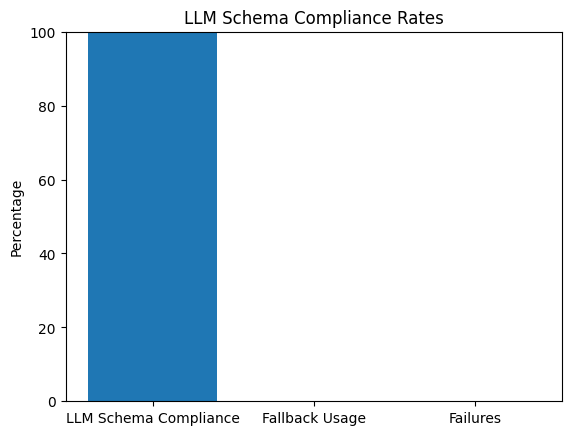

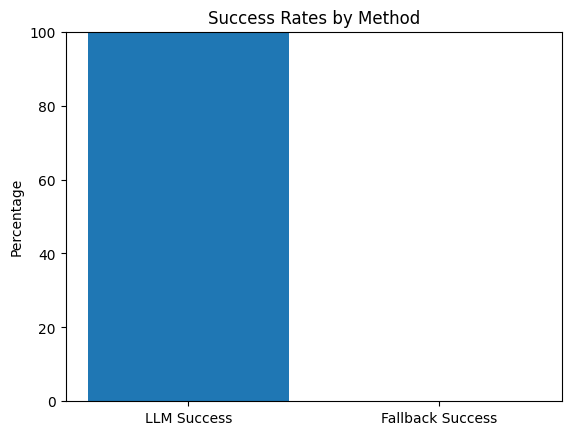

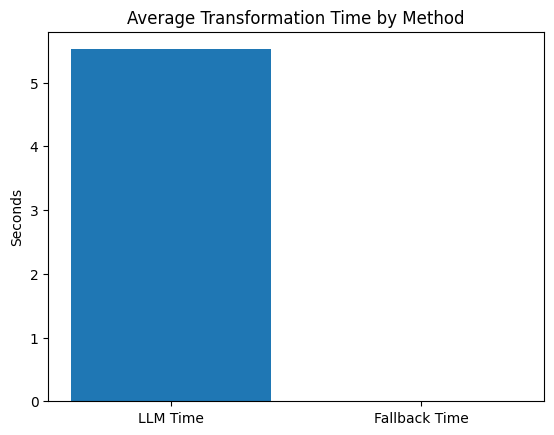


Metrics Summary:
Total Records: 23.00
LLM Success Rate (%): 100.00
Fallback Success Rate (%): 0.00
Average LLM Time (s): 5.52
Average Fallback Time (s): 0.00

Case Studies:
{
  "Successful Examples": [
    {
      "record_id": 808656,
      "method": "llm",
      "success": true,
      "time": 7.4885687828063965,
      "stage": "generation",
      "error": null,
      "entity": "practitioner",
      "model": "mistral",
      "error_type": null,
      "artifact_dir": null,
      "llm_elapsed": null,
      "val_elapsed": null,
      "fb_elapsed": null
    },
    {
      "record_id": 678669,
      "method": "llm",
      "success": true,
      "time": 8.439271688461304,
      "stage": "generation",
      "error": null,
      "entity": "practitioner",
      "model": "mistral",
      "error_type": null,
      "artifact_dir": null,
      "llm_elapsed": null,
      "val_elapsed": null,
      "fb_elapsed": null
    }
  ],
  "Fallback Examples": [],
  "Edge Case Examples": []
}


In [ ]:
# Load combined logs
with open("combined_logs.json", "r") as f:
    logs = json.load(f)

# Convert to DataFrame for analysis
df = pd.DataFrame(logs)

if df.empty:
    print("No logs available.")
else:
    # Normalise method field to lowercase for consistency
    df["method"] = df["method"].str.lower()

    # Schema Compliance Rates
    total_records = len(df)
    success_records = df[df["success"]]
    failed_records = df[~df["success"]]
    fallback_records = df[df["method"] == "fallback"]
    llm_records = df[df["method"] == "llm"]

    compliance_rates = {
        "LLM Schema Compliance (%)": len(llm_records[llm_records["success"]]) / total_records * 100 if total_records else 0,
        "Fallback Usage (%)": len(fallback_records) / total_records * 100 if total_records else 0,
        "Failure Rate (%)": len(failed_records) / total_records * 100 if total_records else 0
    }

    # Schema Compliance
    compliance_data = list(compliance_rates.values())
    plt.figure()
    plt.bar(["LLM Schema Compliance", "Fallback Usage", "Failures"], compliance_data)
    plt.title("LLM Schema Compliance Rates")
    plt.ylabel("Percentage")
    plt.ylim(0, 100)
    plt.show()

    # Success Rates by Method
    llm_success_rate = len(llm_records[llm_records["success"]]) / len(llm_records) * 100 if len(llm_records) else 0
    fallback_success_rate = len(fallback_records[fallback_records["success"]]) / len(fallback_records) * 100 if len(fallback_records) else 0

    plt.figure()
    plt.bar(["LLM Success", "Fallback Success"], [llm_success_rate, fallback_success_rate])
    plt.title("Success Rates by Method")
    plt.ylabel("Percentage")
    plt.ylim(0, 100)
    plt.show()

    # Chart 3: Avg Time by Method
    average_llm_time = llm_records["time"].mean() if not llm_records.empty else 0
    average_fallback_time = fallback_records["time"].mean() if not fallback_records.empty else 0

    performance_data = [average_llm_time, average_fallback_time]
    plt.figure()
    plt.bar(["LLM Time", "Fallback Time"], performance_data)
    plt.title("Average Transformation Time by Method")
    plt.ylabel("Seconds")
    plt.show()

    # Summary Printout
    metrics_summary = {
        "Total Records": total_records,
        "LLM Success Rate (%)": llm_success_rate,
        "Fallback Success Rate (%)": fallback_success_rate,
        "Average LLM Time (s)": average_llm_time,
        "Average Fallback Time (s)": average_fallback_time
    }

    print("\nMetrics Summary:")
    for key, value in metrics_summary.items():
        print(f"{key}: {value:.2f}")

    # Save summary to JSON
    with open("expanded_metrics_summary.json", "w") as f:
        json.dump(metrics_summary, f, indent=2)

    # Case Study Extraction
    successful_examples = success_records.head(2).to_dict(orient="records")
    fallback_examples = fallback_records.head(2).to_dict(orient="records")
    edge_case_examples = fallback_records[fallback_records["time"] > average_fallback_time].head(2).to_dict(orient="records")

    case_studies = {
        "Successful Examples": successful_examples,
        "Fallback Examples": fallback_examples,
        "Edge Case Examples": edge_case_examples
    }

    with open("case_studies.json", "w") as f:
        json.dump(case_studies, f, indent=2)

    print("\nCase Studies:")
    print(json.dumps(case_studies, indent=2))


Cell 17b: Additional Visualisations: Method Breakdown and Time Trends

In [ ]:
# Stacked bar chart for transformation success
success_counts = [
    len(llm_records[llm_records["success"]]),
    len(fallback_records[fallback_records["success"]])
]
failure_counts = [
    len(llm_records[~llm_records["success"]]),
    len(fallback_records[~fallback_records["success"]])
]

bar_width = 0.5
methods = ["LLM", "Fallback"]

plt.figure()
plt.bar(methods, success_counts, label="Success", color="green")
plt.bar(methods, failure_counts, bottom=success_counts, label="Failure", color="red")
plt.title("Transformation Success by Method")
plt.ylabel("Record Count")
plt.legend()
plt.show()

In [ ]:
# Pie chart for schema compliance
compliance_labels = ["LLM Schema Compliance", "Fallback Usage", "Failures"]
compliance_values = [
    compliance_rates["LLM Schema Compliance (%)"],
    compliance_rates["Fallback Usage (%)"],
    compliance_rates["Failure Rate (%)"]
]

plt.figure()
plt.pie(compliance_values, labels=compliance_labels, autopct="%1.1f%%", startangle=140)
plt.title("Schema Compliance Breakdown")
plt.show()


In [ ]:
# Line graph for processing times
plt.figure()
for method in df["method"].unique():
    subset = df[df["method"] == method]
    plt.plot(subset.index, subset["time"], marker="o", label=method)

plt.title("Processing Time Trends by Method")
plt.xlabel("Record Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()


In [ ]:
# import json, pandas as pd
# import matplotlib.pyplot as plt

# with open("combined_logs.json","r") as f:
#     logs = json.load(f)
# df = pd.DataFrame(logs)

# if df.empty:
#     print("No logs to plot.")
# else:
#     for col in ["method","time"]:
#         if col not in df.columns: df[col] = None

#     plt.figure()
#     for method in df["method"].dropna().unique():
#         subset = df[df["method"] == method].reset_index(drop=True)
#         plt.plot(subset.index, subset["time"], marker="o", label=method)
#     plt.title("Processing Time Trends by Method")
#     plt.xlabel("Record Index (per filtered subset)")
#     plt.ylabel("Time (s)")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [ ]:
import seaborn as sns

# Heatmap for success and method correlation
heatmap_data = pd.pivot_table(df, values="time", index="method", columns="success", aggfunc="mean")
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "Average Time (seconds)"})
plt.title("Method and Success Correlation Heatmap")
plt.xlabel("Success (True/False)")
plt.ylabel("Method")
plt.show()


# Cell 18: Inspect Fallback Reasons and Error Breakdown - Fallback Analysis with Timing and Artifact Pointers

In [ ]:
import json, pandas as pd

with open("combined_logs.json", "r", encoding="utf-8") as f:
    logs = json.load(f)
df = pd.DataFrame(logs)

if df.empty:
    print("No logs found.")
else:
    df["method"] = df["method"].str.lower()
    fb = df[df["method"] == "fallback"]

    if fb.empty:
        print("No fallback records.")
    else:
        print("\nFallback breakdown by stage and error type:\n")
        print(fb.groupby(["stage", "error_type"]).size().rename("count"))

        cols = ["record_id", "entity", "stage", "error_type", "artifact_dir", "error", "time"]
        print("\nSample fallback rows (first 10):\n")
        print(fb[cols].head(10).to_string(index=False))

        print("\nEach 'artifact_dir' contains:")
        print("- prompt.txt        (the exact prompt)")
        print("- llm_output.txt    (first ~1200 chars of LLM output)")
        print("- retrieval.json    (RAG documents used)")
        print("- error.json        (error type, message, validation trace if any)")

        # Optional: Filtered views
        print("\nValidation-only fallbacks:")
        print(fb[fb["stage"] == "validation"][cols].head(5).to_string(index=False))

        print("\nGeneration-only fallbacks:")
        print(fb[fb["stage"] == "generation"][cols].head(5).to_string(index=False))


Loads combined_logs.json and isolates fallback records. It then:

Groups fallbacks by stage (generation vs validation) and error_type

Prints a summary count of fallback causes

Displays sample fallback rows with artifact_dir paths for inspection

Offers quick filtering for generation-related vs validation-related fallbacks

# Cell 19: Display Before/After Pairs for Practitioners and Appointments

In [ ]:
# Show all practitioner before/after pairs
print(f"Practitioners: {len(pract_raw['results'])} raw → {len(pract_xf)} transformed")
for i, (before, after) in enumerate(zip(pract_raw['results'], pract_xf), start=1):
    print(f"\nPractitioner {i}")
    print("Before:")
    print(json.dumps(before, indent=2))
    print("After:")
    print(json.dumps(after, indent=2))

# Show first 5 appointment before/after pairs
print(f"\nAppointments: Showing first 5 of {len(appts_raw['results'])}")
for i, before in enumerate(appts_raw['results'][:5], start=1):
    print(f"\nAppointment {i}")
    print("Before:")
    print(json.dumps(before, indent=2))

    # Apply your status and title mapping to simulate a clean transformed version
    transformed = {
        "id": before.get("id"),
        "location_id": before.get("locationId"),
        "patient_id": before.get("customerId"),
        "practitioner_id": before.get("practitionerId"),
        "status": _status_map.get(before.get("status", 1), "draft"),
        "start_time": before.get("startDateTime"),
        "end_time": before.get("endDateTime"),
        "title": (before.get("title") or "").rstrip(".") if before.get("title") else None,
        "description": before.get("description") or before.get("comment") or None
    }

    print("After:")
    print(json.dumps(transformed, indent=2))


Practitioners: 3 raw → 3 transformed

Practitioner 1
Before:
{
  "id": 808656,
  "fullName": "Ms. Mandy Thompson",
  "name": "Mandy Thompson",
  "code": "",
  "fullAddress": "Flat 49\nStacey Junction, South Peter, Cambridgeshire, NG24 2PB, Northern Ireland",
  "locationName": "Marshall Ltd",
  "title": "Ms.",
  "forename": "Mandy",
  "surname": "Thompson",
  "gender": "Female",
  "addressLine1": "Flat 49\nStacey Junction",
  "addressLine2": null,
  "addressLine3": "",
  "addressLine4": "",
  "addressLine5": "",
  "postCode": "NG24 2PB",
  "telephone": "",
  "mobile": "07533 808703",
  "email": "louis.mitchell@example.org",
  "fax": "",
  "web": "",
  "online": true,
  "status": 1,
  "type": "Owner",
  "contractNumber": "",
  "onlineGuid": "5c2e5024-a33f-34b0-9da5-6446d2e3e466",
  "defaultLocationId": 932896,
  "serviceTypeId": 1,
  "regNumber": "",
  "commissionFlatRate": 0,
  "commissionPercent": 0,
  "employmentStatus": "Owner",
  "timeSlot": 0,
  "taxNo": "",
  "alerts": [],
  "loca

# Cell 20: Producing a dataset to save the results of the testing

In [ ]:
# Derive model slug for folder naming and filenames
model_slug = OLLAMA_MODEL.replace(":", "_").replace("/", "_")
model_dir = f"evaluation_metrics/per_model/{model_slug}"
os.makedirs(model_dir, exist_ok=True)

# Reload logs
with open("combined_logs.json", "r", encoding="utf-8") as f:
    logs = json.load(f)
df = pd.DataFrame(logs)

if df.empty:
    print("No logs to archive.")
else:
    df["method"] = df["method"].str.lower()

    # Split by method
    llm_df = df[df["method"] == "llm"]
    fb_df  = df[df["method"] == "fallback"]
    fail_df = df[~df["success"]]

    # Per-entity (LLM-only) slices
    prac_llm = llm_df[llm_df["entity"] == "practitioner"]
    appt_llm = llm_df[llm_df["entity"] == "appointment"]

    # Core metrics (cumulative)
    metrics = {
        "Model": OLLAMA_MODEL,
        "Total Records": len(df),

        "LLM Success Rate (%)": len(llm_df[llm_df["success"]]) / len(llm_df) * 100 if not llm_df.empty else 0,
        "Fallback Success Rate (%)": len(fb_df[fb_df["success"]]) / len(fb_df) * 100 if not fb_df.empty else 0,
        "LLM Schema Compliance (%)": len(llm_df[llm_df["success"]]) / len(df) * 100 if not df.empty else 0,
        "Fallback Usage (%)": len(fb_df) / len(df) * 100 if not df.empty else 0,
        "Failure Rate (%)": len(fail_df) / len(df) * 100 if not df.empty else 0,

        "Average LLM Time (s)": llm_df["time"].mean() if not llm_df.empty else 0,
        "Average Fallback Time (s)": fb_df["time"].mean() if not fb_df.empty else 0,
        "LLM Latency Range (s)": f"{llm_df['time'].min():.2f} – {llm_df['time'].max():.2f}" if not llm_df.empty else "0.00 – 0.00",
        "Fallback Latency Range (s)": f"{fb_df['time'].min():.2f} – {fb_df['time'].max():.2f}" if not fb_df.empty else "0.00 – 0.00",
    }

    # Per-entity (LLM-only) metrics
    metrics.update({
        "Num Practitioners": int((df["entity"] == "practitioner").sum()),
        "Num Appointments": int((df["entity"] == "appointment").sum()),

        "Practitioner LLM Avg Time (s)": prac_llm["time"].mean() if not prac_llm.empty else 0,
        "Practitioner LLM Latency Range (s)": f"{prac_llm['time'].min():.2f} – {prac_llm['time'].max():.2f}" if not prac_llm.empty else "0.00 – 0.00",

        "Appointment LLM Avg Time (s)": appt_llm["time"].mean() if not appt_llm.empty else 0,
        "Appointment LLM Latency Range (s)": f"{appt_llm['time'].min():.2f} – {appt_llm['time'].max():.2f}" if not appt_llm.empty else "0.00 – 0.00",
    })

    # Save metrics summary as JSON
    with open(os.path.join(model_dir, "metrics_summary.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    # Save metrics summary as CSV (model-named)
    csv_filename = f"metrics_summaryy_{model_slug}.csv"
    pd.DataFrame([metrics]).to_csv(os.path.join(model_dir, csv_filename), index=False)

    # Also store a copy in a global summary folder for later comparison
    summary_dir = "evaluation_metrics/summaries"
    os.makedirs(summary_dir, exist_ok=True)
    pd.DataFrame([metrics]).to_csv(os.path.join(summary_dir, f"{model_slug}.csv"), index=False)

    # Archive logs and case studies
    with open(os.path.join(model_dir, "combined_logs.json"), "w") as f:
        json.dump(logs, f, indent=2)

    if os.path.exists("case_studies.json"):
        with open("case_studies.json", "r", encoding="utf-8") as f:
            case_studies = json.load(f)
        with open(os.path.join(model_dir, "case_studies.json"), "w") as f:
            json.dump(case_studies, f, indent=2)

    print(f"Archived run under: {model_dir}")
    print(f"Metrics CSV: {csv_filename}")
    print(f" Summary copy saved to: {summary_dir}/{model_slug}.csv")


# Cell 21: Aggregating the datasets

In [ ]:
# Folder containing per-model metrics CSVs
summary_dir = "evaluation_metrics/summaries"

# Find all CSVs in the summaries folder
csv_files = [f for f in os.listdir(summary_dir) if f.endswith(".csv")]

if not csv_files:
    print("No model summaries found.")
else:
    all_dfs = []
    for file in csv_files:
        path = os.path.join(summary_dir, file)
        try:
            df_tests = pd.read_csv(path)
            all_dfs.append(df_tests)
        except Exception as e:
            print(f"Failed to load {file}: {e}")

    if all_dfs:
        comparison_df = pd.concat(all_dfs, ignore_index=True)
        display(comparison_df.sort_values("LLM Schema Compliance (%)", ascending=False))
    else:
        print("No valid summary CSVs loaded.")


In [ ]:
if all_dfs:
    comparison_df = pd.concat(all_dfs, ignore_index=True)

    # Save aggregated summary
    agg_path = os.path.join(summary_dir, "aggregated_comparison.csv")
    comparison_df.to_csv(agg_path, index=False)

    display(comparison_df.sort_values("LLM Schema Compliance (%)", ascending=False))
    print(f"\nAggregated comparison saved to {agg_path}")

# Cell 22: Inspect Per-Stage Logs (verbose)

In [ ]:
# Inspect verbose per-stage logs for the current model (robust to missing columns)

import os
import pandas as pd

# Resolve model-scoped stage log path
model_slug = OLLAMA_MODEL.replace(":", "_").replace("/", "_")
stage_log_path = os.path.join("evaluation_metrics", "per_model", model_slug, "stage_logs.jsonl")

if not os.path.exists(stage_log_path):
    print(
        f"No stage log found for this model:\n{stage_log_path}\n"
        "Ensure stage_log() is defined and the updated transform_entity() is in use."
    )
else:
    # Read JSONL into a DataFrame
    df_stage = pd.read_json(stage_log_path, lines=True)

    # Quick sanity checks
    print(f"Loaded stage logs: {len(df_stage)} events from {stage_log_path}")
    display(df_stage.head())

    # Event counts summary
    print("\nEvent counts:")
    display(df_stage["event"].value_counts().rename("count").to_frame())

    # Helper: summarise a numeric series (guarded for empties)
    def _summarise(series):
        if series.empty:
            return {"n": 0, "min": 0.0, "median": 0.0, "mean": 0.0, "max": 0.0}
        s = pd.to_numeric(series, errors="coerce").dropna()
        if s.empty:
            return {"n": 0, "min": 0.0, "median": 0.0, "mean": 0.0, "max": 0.0}
        desc = s.describe()
        return {
            "n": int(desc["count"]),
            "min": round(desc["min"], 2),
            "median": round(desc["50%"], 2),
            "mean": round(s.mean(), 2),
            "max": round(desc["max"], 2),
        }

    # Helper: safely slice a numeric column from a masked subset
    def _col_slice(df, mask, colname):
        if colname not in df.columns:
            return pd.Series([], dtype=float)
        return pd.to_numeric(df.loc[mask, colname], errors="coerce").dropna()

    # LLM response timings by entity
    print("\nLLM elapsed (seconds) by entity:")
    rows = []
    for entity in ("practitioner", "appointment"):
        mask = (df_stage["event"] == "llm_response") & (df_stage.get("entity") == entity)
        stats = _summarise(_col_slice(df_stage, mask, "llm_elapsed"))
        stats["entity"] = entity
        rows.append(stats)
    display(pd.DataFrame(rows)[["entity", "n", "min", "median", "mean", "max"]])

    # Fallback timings by entity (only present if fallbacks ran)
    print("\nFallback elapsed (seconds) by entity (where applicable):")
    rows_fb = []
    for entity in ("practitioner", "appointment"):
        mask = (df_stage["event"] == "fallback_success") & (df_stage.get("entity") == entity)
        stats = _summarise(_col_slice(df_stage, mask, "fallback_elapsed"))
        stats["entity"] = entity
        rows_fb.append(stats)
    display(pd.DataFrame(rows_fb)[["entity", "n", "min", "median", "mean", "max"]])

    # Total elapsed for validated LLM path by entity
    print("\nTotal elapsed (seconds) for successful LLM validations by entity:")
    rows_tot = []
    for entity in ("practitioner", "appointment"):
        mask = (df_stage["event"] == "validated") & (df_stage.get("entity") == entity) & (df_stage.get("method") == "llm")
        stats = _summarise(_col_slice(df_stage, mask, "total_elapsed"))
        stats["entity"] = entity
        rows_tot.append(stats)
    display(pd.DataFrame(rows_tot)[["entity", "n", "min", "median", "mean", "max"]])

    print(
        "\nNote: If practitioner counts (n) are much lower than appointments, "
        "acknowledge this class imbalance in your methodology and report ranges alongside means."
    )


# Cell 23: Comparative Visualisations (Cross-Model)

Do not run this cell until every model has been tested.

In [ ]:
# # Cell 23: Comparative Visualisations (Cross-Model)

# # Folder containing per-model metrics CSVs
# summary_dir = "evaluation_metrics/summaries"
# csv_files = [f for f in os.listdir(summary_dir) if f.endswith(".csv")]

# if not csv_files:
#     print("No model summaries found.")
# else:
#     # Load all model summaries
#     all_dfs = []
#     for file in csv_files:
#         path = os.path.join(summary_dir, file)
#         try:
#             df_temp = pd.read_csv(path)
#             all_dfs.append(df_temp)
#         except Exception as e:
#             print(f"Failed to load {file}: {e}")
#     if not all_dfs:
#         print("No valid summary CSVs loaded.")
#     else:
#         comparison_df = pd.concat(all_dfs, ignore_index=True)

#         # Box Plot: LLM Latency by Model
#         plt.figure(figsize=(8, 6))
#         sns.boxplot(
#             data=comparison_df,
#             x="Model",
#             y="Average LLM Time (s)"
#         )
#         plt.title("Distribution of Average LLM Latency by Model")
#         plt.ylabel("Seconds")
#         plt.xlabel("Model")
#         plt.show()

#         # Bar Chart: Stage-Level Timing
#         stage_data = comparison_df[[
#             "Model",
#             "Practitioner LLM Avg Time (s)",
#             "Appointment LLM Avg Time (s)"
#         ]].melt(id_vars="Model", var_name="Stage", value_name="Time (s)")

#         plt.figure(figsize=(8, 6))
#         sns.barplot(data=stage_data, x="Model", y="Time (s)", hue="Stage")
#         plt.title("Stage-Level Avg LLM Time (Practitioner vs Appointment)")
#         plt.ylabel("Seconds")
#         plt.xlabel("Model")
#         plt.legend(title="Stage", bbox_to_anchor=(1.05, 1), loc="upper left")
#         plt.show()

#         # Compliance / Fallback / Failures
#         metrics_to_plot = ["LLM Schema Compliance (%)", "Fallback Usage (%)", "Failure Rate (%)"]
#         df_melt = comparison_df.melt(id_vars="Model", value_vars=metrics_to_plot,
#                                      var_name="Metric", value_name="Percentage")

#         plt.figure(figsize=(8, 6))
#         sns.barplot(data=df_melt, x="Model", y="Percentage", hue="Metric")
#         plt.title("Compliance, Fallback, and Failure Rates")
#         plt.ylabel("Percentage (%)")
#         plt.xlabel("Model")
#         plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
#         plt.show()

#         # Concise and brief textual summary
#         print("\nQuick Metrics Overview:")
#         display(comparison_df[[
#             "Model",
#             "LLM Success Rate (%)",
#             "Average LLM Time (s)",
#             "Practitioner LLM Avg Time (s)",
#             "Appointment LLM Avg Time (s)"
#         ]])
